# Vibe 21 — Hourly Demand Surrogate Training Walkthrough

This notebook documents the **demand-management hourly** ML pipeline for Building 100 Twin:

1. EnergyPlus DR farm → hourly `facility_kw` rows  
2. Feature compile (lags, strategy one-hots, no future leakage)  
3. Day-grouped cross-validation + HistGradientBoosting champion  
4. Joblib artifact → Flask → Unity digital twin

**Status:** `CANDIDATE` · **Provenance:** `ENERGYPLUS_SIMULATED` (native EnergyPlus)  
**Not** investment-grade M&V — a screening / what-if surrogate for Unity DR scrubbing.

### Reproduce (CLI)

```bash
python vibe_code_apps_21/tools/dm_hourly_farm.py --engine native --reuse-existing
python vibe_code_apps_21/ml/tune_demand_hourly.py
python vibe_code_apps_21/ml/writeup_demand_hourly.py
```

This notebook **loads the existing farm parquet** (no EnergyPlus required) and re-runs a compact train/eval pass so GitHub can show live outputs.

## 0 — Paths & imports

Training data and the shipped joblib live under `~/wattlab_workspace` (not in git). Repo code lives under `vibe_code_apps_21/ml/`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold

REPO = Path("..").resolve()  # vibe_code_apps_21 when cwd is notebooks/
if not (REPO / "ml" / "feature_compile_dm.py").exists():
    REPO = Path.cwd().resolve()
    if not (REPO / "ml" / "feature_compile_dm.py").exists():
        REPO = Path.cwd().parent.resolve()

ML = REPO / "ml"
sys.path.insert(0, str(ML))

from feature_compile_dm import FEATURE_COLS, TARGET_COL, GROUP_COL, compile_features, matrix_xy, peak_mask
from train_demand_hourly import load_farm_frame, _metrics

WS = Path.home() / "wattlab_workspace"
PARQUET = WS / "reports" / "dm_hourly_farm" / "dm_hourly_rows.parquet"
MODEL = WS / "models" / "demand_hourly_v1.joblib"
CARD = WS / "models" / "demand_hourly_v1_model_card.json"
FIGS = REPO / "vibe21_agent_spec" / "figures" / "dm_hourly"

print("REPO     :", REPO)
print("Workspace:", WS)
print("Parquet  :", PARQUET, "exists=", PARQUET.exists())
print("Model    :", MODEL, "exists=", MODEL.exists())
print("Figures  :", FIGS, "exists=", FIGS.exists())
assert PARQUET.exists(), "Farm parquet missing — run dm_hourly_farm.py first"

REPO     : C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_21
Workspace: C:\Users\ben\wattlab_workspace
Parquet  : C:\Users\ben\wattlab_workspace\reports\dm_hourly_farm\dm_hourly_rows.parquet exists= True
Model    : C:\Users\ben\wattlab_workspace\models\demand_hourly_v1.joblib exists= True
Figures  : C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_21\vibe21_agent_spec\figures\dm_hourly exists= True


## 1 — Load & describe the EnergyPlus farm dataset

Each row is **one hour** of a single-day DR simulation (hour-ending 1–24).  
Strategies include baseline, precool, deadband, chiller shed, etc. Interval = **1 hour**.

In [2]:
df = load_farm_frame(PARQUET)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total hourly rows        : {len(df):,}")
print(f"Unique simulation days   : {df['day'].nunique()}")
print(f"Unique simulation_ids    : {df['simulation_id'].nunique()}")
print(f"Hour-ending range        : {int(df['hour_ending'].min())} – {int(df['hour_ending'].max())}")
print(f"Hours per simulation     : {df.groupby('simulation_id').size().mode().iloc[0]}")
print(f"Time interval            : 1 hour (hour-ending convention)")
print()
print("Provenance:")
print(df["provenance_source"].value_counts().to_string())
if "epw" in df.columns:
    print()
    print("EPW files (sample):", df["epw"].dropna().astype(str).unique()[:5].tolist())
print()
print("Strategies:")
print(df["strategy_id"].value_counts().sort_index().to_string())
print()
print("Phases:")
print(df["phase"].value_counts().to_string())
print()
print("Target facility_kw (kW):")
print(df["facility_kw"].describe().to_string())
print()
print("Columns (", len(df.columns), "):")
print(list(df.columns))
df.head(3)

DATASET OVERVIEW
Total hourly rows        : 4,560
Unique simulation days   : 40
Unique simulation_ids    : 190
Hour-ending range        : 1 – 24
Hours per simulation     : 24
Time interval            : 1 hour (hour-ending convention)

Provenance:
provenance_source
ENERGYPLUS_SIMULATED    4560

EPW files (sample): ['amy.epw']

Strategies:
strategy_id
baseline               960
chiller_off            960
deadband_10f           960
hvac_off               240
loadshed_p5f           240
precool_chiller_off    240
precool_shift          960

Phases:
phase
baseline    3500
precool      300
recovery     300
relax        240
shed         220

Target facility_kw (kW):
count    4560.000000
mean      169.702180
std       123.006541
min        38.044000
25%        48.449000
50%       177.949000
75%       245.871750
max       484.236000

Columns ( 28 ):
['schema_version', 'simulation_id', 'twin_run_id', 'day', 'hour_ending', 'dow', 'oat_c', 'rh_pct', 'ghi', 'occupied', 'strategy_id', 'phase', 'in_dr

,schema_version,simulation_id,twin_run_id,day,hour_ending,dow,oat_c,rh_pct,ghi,occupied,...,chw_avail,fan_avail,facility_kw,cooling_kw,max_zone_temp_c,unmet_hours_flag,provenance_source,idf_sha256,epw,mode
0,vibe21.dm_hourly_row.v1,ops11_2025-06-23_baseline,geo_b100_dual_ahu_shape_ops11,2025-06-23,1,Monday,33.6,49.0,204.0,False,...,1.0,1.0,48.449,None,None,False,ENERGYPLUS_SIMULATED,df74c04ecfb80afe04fc87136f955eb6de0e6ce8754bdd...,amy.epw,baseline
1,vibe21.dm_hourly_row.v1,ops11_2025-06-23_baseline,geo_b100_dual_ahu_shape_ops11,2025-06-23,2,Monday,32.3,53.0,57.0,False,...,1.0,1.0,48.449,None,None,False,ENERGYPLUS_SIMULATED,df74c04ecfb80afe04fc87136f955eb6de0e6ce8754bdd...,amy.epw,baseline
2,vibe21.dm_hourly_row.v1,ops11_2025-06-23_baseline,geo_b100_dual_ahu_shape_ops11,2025-06-23,3,Monday,31.3,57.0,0.0,False,...,1.0,1.0,48.449,None,None,False,ENERGYPLUS_SIMULATED,df74c04ecfb80afe04fc87136f955eb6de0e6ce8754bdd...,amy.epw,baseline


### Calendar / weather coverage

Farm days are stratified (cool / mild / hot / extreme × weekday/weekend) against the Twin AMY EPW.

In [3]:
print("Day-of-week counts:")
print(df["dow"].value_counts().to_string())
print()
print("OAT °C  :", f"min={df['oat_c'].min():.1f}  mean={df['oat_c'].mean():.1f}  max={df['oat_c'].max():.1f}")
print("RH %    :", f"min={df['rh_pct'].min():.1f}  mean={df['rh_pct'].mean():.1f}  max={df['rh_pct'].max():.1f}")
print()
# Peak window physics means (14–16 hour-ending)
peak = df[(df["hour_ending"] > 14) & (df["hour_ending"] <= 16)]
print(f"Peak-window rows (hour_ending 15–16): {len(peak):,}")
peak_means = peak.groupby("strategy_id")["facility_kw"].mean().sort_values(ascending=False)
baseline = peak_means.get("baseline", np.nan)
print("Mean facility_kw in peak window by strategy:")
for sid, kw in peak_means.items():
    delta = kw - baseline if np.isfinite(baseline) else float("nan")
    print(f"  {sid:28s}  {kw:7.1f} kW   Δ vs baseline {delta:+6.1f} kW")

Day-of-week counts:
dow
Sunday       1368
Saturday      840
Monday        720
Tuesday       696
Thursday      360
Friday        288
Wednesday     288

OAT °C  : min=-9.7  mean=18.1  max=37.8
RH %    : min=23.0  mean=69.4  max=98.0

Peak-window rows (hour_ending 15–16): 380
Mean facility_kw in peak window by strategy:
  loadshed_p5f                    250.6 kW   Δ vs baseline   +2.8 kW
  baseline                        247.8 kW   Δ vs baseline   +0.0 kW
  deadband_10f                    238.9 kW   Δ vs baseline   -8.9 kW
  precool_shift                   237.1 kW   Δ vs baseline  -10.7 kW
  precool_chiller_off             165.5 kW   Δ vs baseline  -82.3 kW
  hvac_off                        161.4 kW   Δ vs baseline  -86.3 kW
  chiller_off                     153.1 kW   Δ vs baseline  -94.7 kW


## 2 — Feature engineering (no future leakage)

`compile_features` adds:

- same-day lags (`facility_kw_lag1/2`, `oat_lag1`) grouped by `simulation_id`
- one-hot `phase_*` and `strategy_*`
- `is_weekend`

**Target:** `facility_kw`  
**Group for CV:** `day` (so we never train on the same calendar day we test)

In [4]:
feat = compile_features(df)
X, y, groups, cols = matrix_xy(df)
pk = peak_mask(df)

print("=" * 60)
print("FEATURE MATRIX")
print("=" * 60)
print(f"X shape          : {X.shape}  (rows × features)")
print(f"y shape          : {y.shape}")
print(f"n_features       : {len(cols)}")
print(f"Target column    : {TARGET_COL}")
print(f"Group column     : {GROUP_COL}  (unique days = {len(np.unique(groups))})")
print(f"Peak-mask rows   : {int(pk.sum()):,}  ({100*pk.mean():.1f}% of rows)")
print()
print("Feature columns:")
for i, c in enumerate(cols, 1):
    print(f"  {i:2d}. {c}")
print()
print("Feature frame sample (engineered):")
display(feat[cols + [TARGET_COL]].head(5))

FEATURE MATRIX
X shape          : (4560, 29)  (rows × features)
y shape          : (4560,)
n_features       : 29
Target column    : facility_kw
Group column     : day  (unique days = 40)
Peak-mask rows   : 380  (8.3% of rows)

Feature columns:
   1. hour_ending
   2. oat_c
   3. rh_pct
   4. ghi
   5. occupied
   6. in_dr_window
   7. precool_f
   8. relax_clg_f
   9. relax_htg_f
  10. dat_delta_f
  11. chw_avail
  12. fan_avail
  13. deadband_target_f
  14. facility_kw_lag1
  15. facility_kw_lag2
  16. oat_lag1
  17. phase_baseline
  18. phase_precool
  19. phase_relax
  20. phase_shed
  21. phase_recovery
  22. strategy_baseline
  23. strategy_precool_shift
  24. strategy_deadband_10f
  25. strategy_chiller_off
  26. strategy_loadshed_p5f
  27. strategy_hvac_off
  28. strategy_precool_chiller_off
  29. is_weekend

Feature frame sample (engineered):


,hour_ending,oat_c,rh_pct,ghi,occupied,in_dr_window,precool_f,relax_clg_f,relax_htg_f,dat_delta_f,...,phase_recovery,strategy_baseline,strategy_precool_shift,strategy_deadband_10f,strategy_chiller_off,strategy_loadshed_p5f,strategy_hvac_off,strategy_precool_chiller_off,is_weekend,facility_kw
0,1,-3.8,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,56.401
1,1,-3.8,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,56.401
2,1,-3.8,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,56.401
3,1,-3.8,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,56.401
4,2,-4.4,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,51.811


## 3 — Train / evaluate with GroupKFold by day

Persistence baseline = predict `facility_kw_lag1` (yesterday-hour within the same sim is not used — same-day lag only).

Champion family for shipping: **HistGradientBoostingRegressor** (tuned params from `tune_demand_hourly.py`).

In [5]:
# Tuned champion params (see vibe21_agent_spec/DEMAND_HOURLY_SURROGATE_RESULTS.md)
HGB_PARAMS = dict(
    learning_rate=0.08,
    max_depth=5,
    max_iter=200,
    min_samples_leaf=20,
    random_state=21,
)

n_splits = min(5, max(2, len(np.unique(groups))))
gkf = GroupKFold(n_splits=n_splits)
lag_i = cols.index("facility_kw_lag1")

oof = np.zeros_like(y)
pers_oof = np.zeros_like(y)
fold_rows = []

print(f"Running GroupKFold n_splits={n_splits} …")
for fold, (tr, te) in enumerate(gkf.split(X, y, groups), 1):
    model = HistGradientBoostingRegressor(**HGB_PARAMS)
    model.fit(X[tr], y[tr])
    pred = model.predict(X[te])
    oof[te] = pred
    pers_oof[te] = X[te, lag_i]
    m = _metrics(y[te], pred, pk[te])
    p = _metrics(y[te], pers_oof[te], pk[te])
    fold_rows.append({"fold": fold, "n_test": len(te), **{f"hgb_{k}": v for k, v in m.items()},
                      **{f"pers_{k}": v for k, v in p.items()}})
    print(f"  fold {fold}: n_test={len(te):4d}  HGB MAE={m['mae']:.2f}  peak MAE={m['mae_peak_14_16']:.2f}  "
          f"| pers peak MAE={p['mae_peak_14_16']:.2f}")

fold_df = pd.DataFrame(fold_rows)
print()
print("Per-fold summary:")
display(fold_df.round(2))

hgb_all = _metrics(y, oof, pk)
pers_all = _metrics(y, pers_oof, pk)
print()
print("=" * 60)
print("OUT-OF-FOLD OVERALL")
print("=" * 60)
print(f"HGB  MAE={hgb_all['mae']:.2f} kW   peak(14-16) MAE={hgb_all['mae_peak_14_16']:.2f} kW")
print(f"Pers MAE={pers_all['mae']:.2f} kW   peak(14-16) MAE={pers_all['mae_peak_14_16']:.2f} kW")
print(f"Beats persistence on peak MAE: {hgb_all['mae_peak_14_16'] < pers_all['mae_peak_14_16']}")

Running GroupKFold n_splits=5 …


  fold 1: n_test= 912  HGB MAE=19.06  peak MAE=17.26  | pers peak MAE=26.45


  fold 2: n_test= 912  HGB MAE=14.20  peak MAE=16.24  | pers peak MAE=19.11


  fold 3: n_test= 912  HGB MAE=18.24  peak MAE=18.10  | pers peak MAE=16.79


  fold 4: n_test= 912  HGB MAE=18.09  peak MAE=12.95  | pers peak MAE=25.68


  fold 5: n_test= 912  HGB MAE=17.63  peak MAE=15.84  | pers peak MAE=17.04

Per-fold summary:


,fold,n_test,hgb_rmse,hgb_mae,hgb_rmse_peak_14_16,hgb_mae_peak_14_16,pers_rmse,pers_mae,pers_rmse_peak_14_16,pers_mae_peak_14_16
0,1,912,30.15,19.06,28.04,17.26,54.71,27.39,57.71,26.45
1,2,912,25.42,14.20,26.32,16.24,36.38,12.72,48.56,19.11
2,3,912,31.64,18.24,22.50,18.10,46.90,20.36,48.29,16.79
3,4,912,27.31,18.09,20.24,12.95,55.46,25.44,66.65,25.68
4,5,912,32.58,17.63,22.99,15.84,47.13,19.11,49.76,17.04



OUT-OF-FOLD OVERALL
HGB  MAE=17.44 kW   peak(14-16) MAE=16.08 kW
Pers MAE=21.01 kW   peak(14-16) MAE=21.01 kW
Beats persistence on peak MAE: True


### Fit champion on all rows (same as shipping recipe)

In [6]:
champion = HistGradientBoostingRegressor(**HGB_PARAMS)
champion.fit(X, y)
in_sample = champion.predict(X)
print(f"In-sample MAE (sanity, not CV): {mean_absolute_error(y, in_sample):.2f} kW")
print(f"In-sample RMSE               : {np.sqrt(mean_squared_error(y, in_sample)):.2f} kW")

In-sample MAE (sanity, not CV): 7.30 kW
In-sample RMSE               : 14.11 kW


## 4 — Quick plots (dataset + OOF residuals)

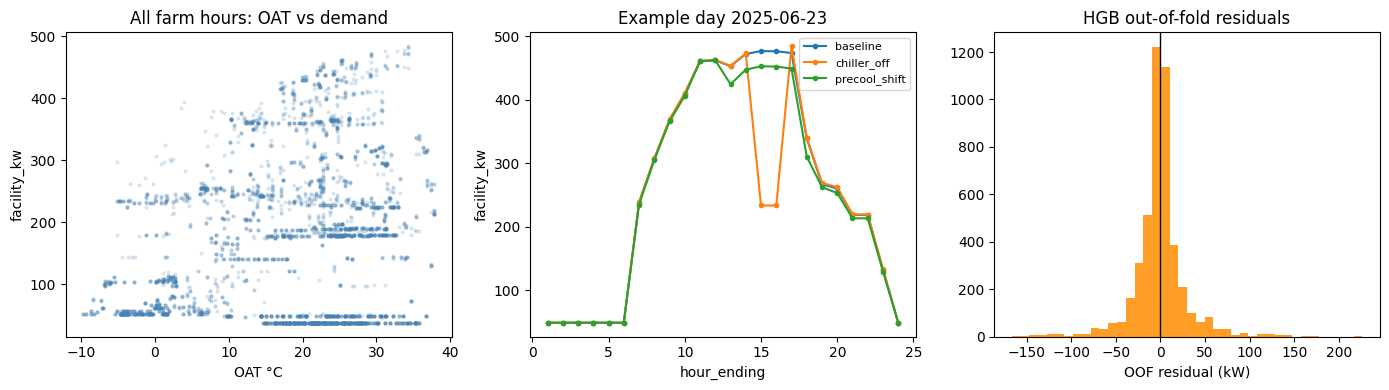

Plotted example day=2025-06-23; residual mean=-0.65 std=29.53


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.scatter(df["oat_c"], df["facility_kw"], s=4, alpha=0.15, c="steelblue")
ax.set_xlabel("OAT °C")
ax.set_ylabel("facility_kw")
ax.set_title("All farm hours: OAT vs demand")

ax = axes[1]
sample_day = df["day"].value_counts().index[0]
sub = df[(df["day"] == sample_day) & (df["strategy_id"].isin(["baseline", "precool_shift", "chiller_off"]))]
for sid, g in sub.groupby("strategy_id"):
    g = g.sort_values("hour_ending")
    ax.plot(g["hour_ending"], g["facility_kw"], marker="o", ms=3, label=sid)
ax.set_xlabel("hour_ending")
ax.set_ylabel("facility_kw")
ax.set_title(f"Example day {sample_day}")
ax.legend(fontsize=8)

ax = axes[2]
resid = y - oof
ax.hist(resid, bins=40, color="darkorange", alpha=0.85)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("OOF residual (kW)")
ax.set_title("HGB out-of-fold residuals")

plt.tight_layout()
plt.show()
print(f"Plotted example day={sample_day}; residual mean={resid.mean():.2f} std={resid.std():.2f}")

### Shipped writeup figures (from `vibe21_agent_spec/figures/dm_hourly/`)

fig_leaderboard.png → True


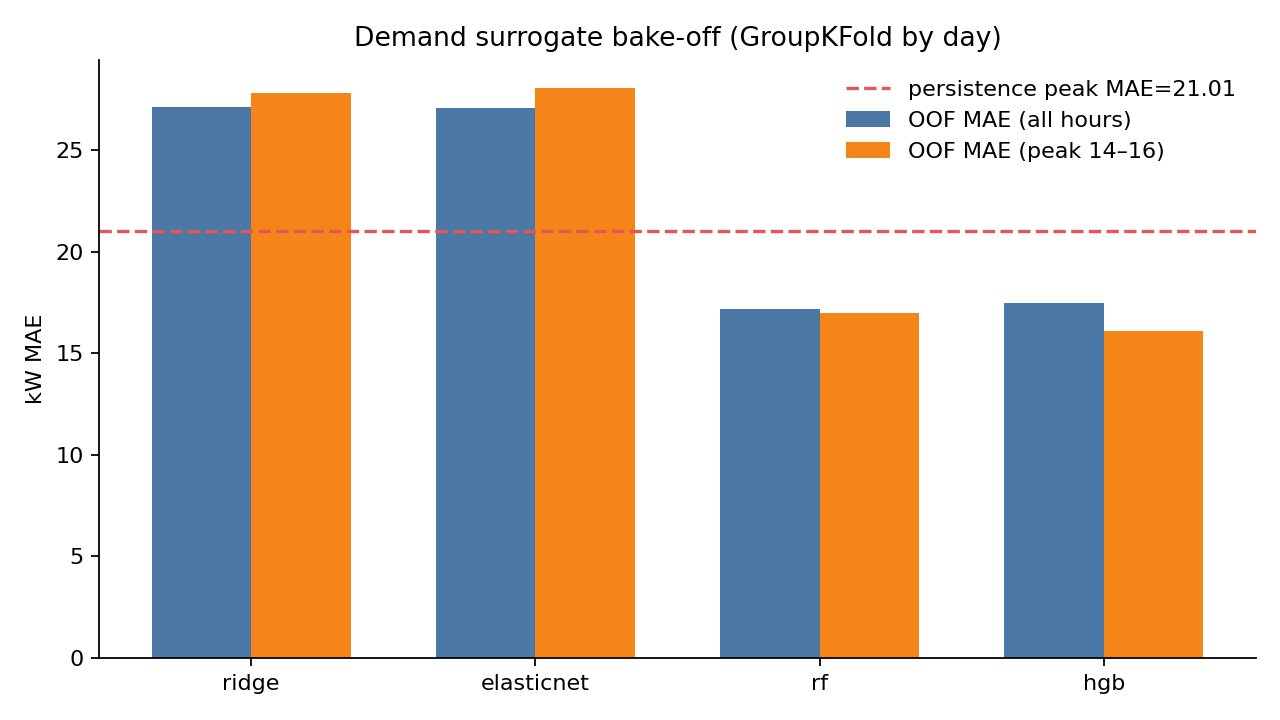

fig_strategy_peak.png → True


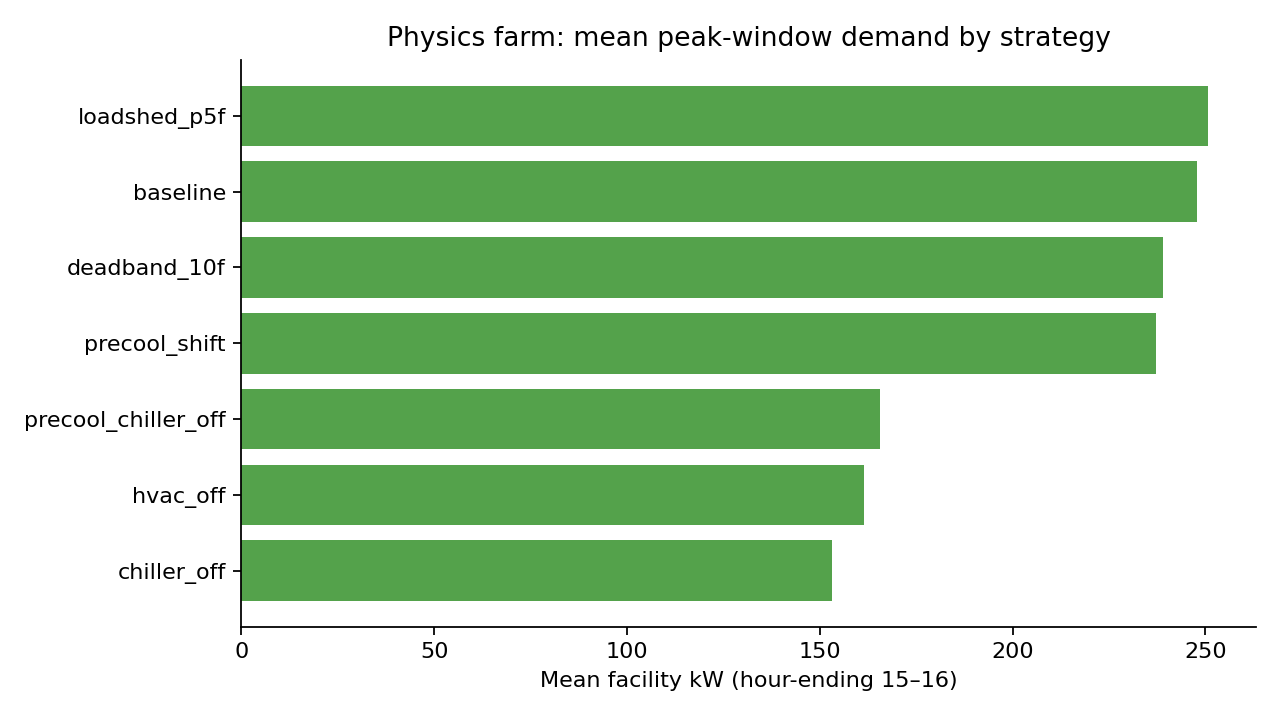

fig_oat_vs_kw.png → True


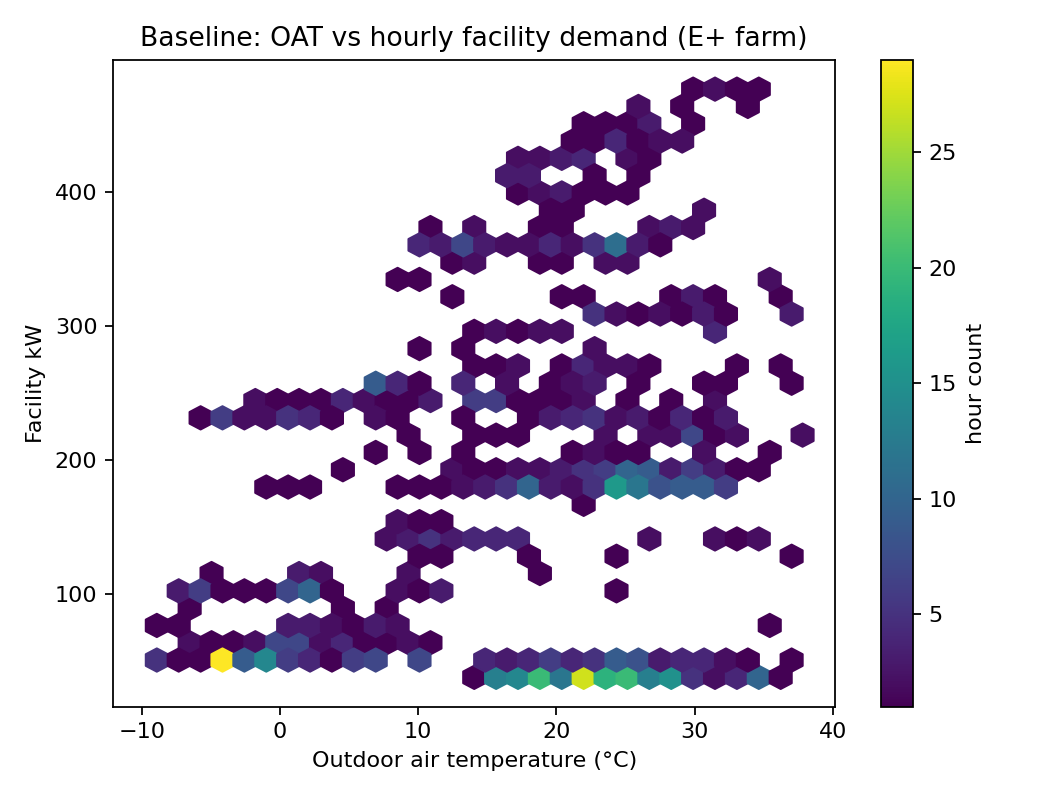

fig_example_day.png → True


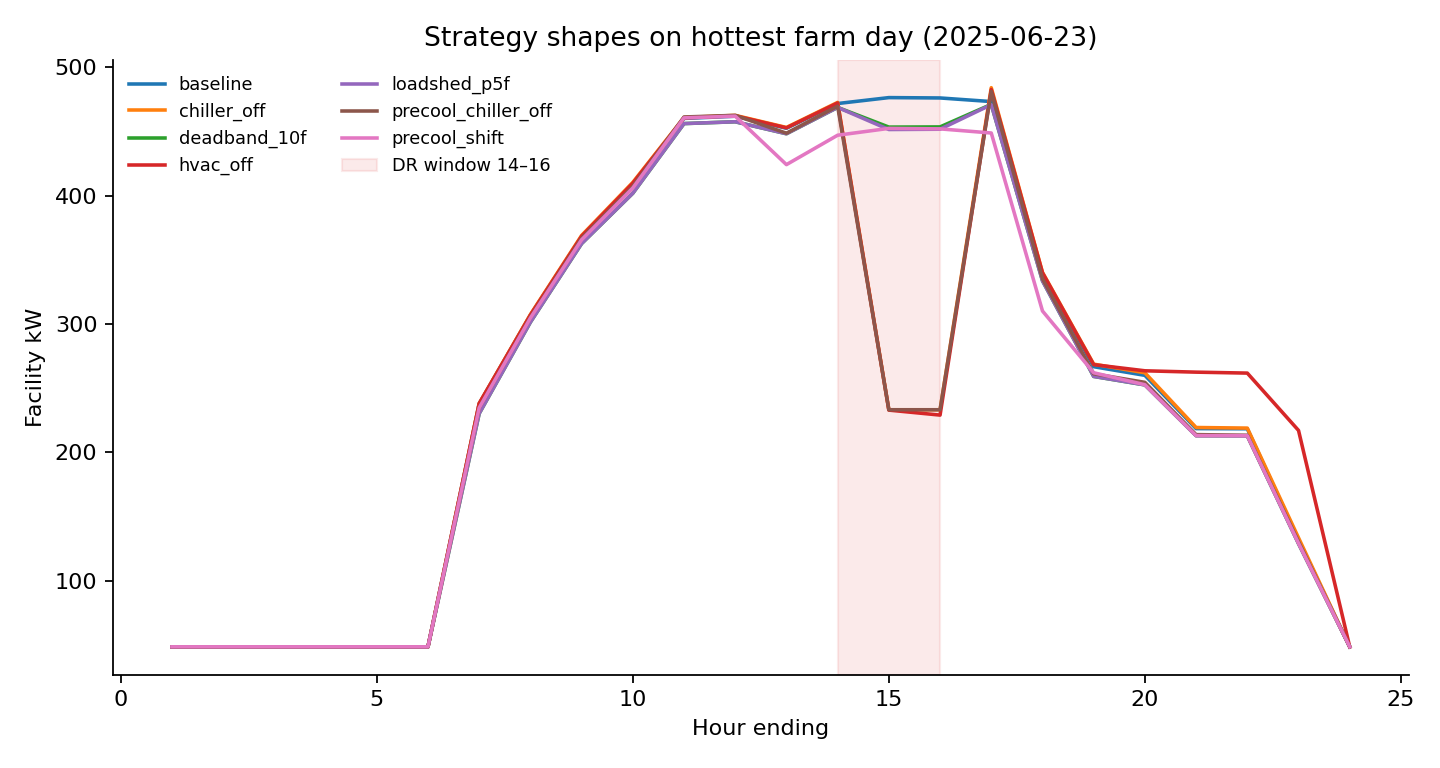

In [8]:
for name in ("fig_leaderboard.png", "fig_strategy_peak.png", "fig_oat_vs_kw.png", "fig_example_day.png"):
    p = FIGS / name
    print(name, "→", p.exists())
    if p.exists():
        display(Image(filename=str(p)))

## 5 — Shipped joblib artifact & model card

In [9]:
if MODEL.exists():
    bundle = joblib.load(MODEL)
    print("Loaded:", MODEL)
    print("Bundle type:", type(bundle))
    if isinstance(bundle, dict):
        print("Keys:", list(bundle.keys()))
        est = bundle.get("model") or bundle.get("estimator") or bundle.get("regressor")
        print("Estimator:", type(est).__name__ if est is not None else None)
        if "feature_cols" in bundle:
            print("feature_cols match FEATURE_COLS:", bundle["feature_cols"] == FEATURE_COLS)
    else:
        print("Estimator:", type(bundle).__name__)
else:
    print("No joblib at", MODEL, "— train/tune CLI writes it there.")

if CARD.exists():
    card = json.loads(CARD.read_text(encoding="utf-8"))
    print()
    print("Model card (excerpt):")
    for k in ("model_id", "model_status", "provenance_source", "engine", "sklearn_version",
              "n_rows", "n_days", "peak_oof_mae", "artifact_sha256"):
        if k in card:
            print(f"  {k}: {card[k]}")
    # print compact JSON head
    print()
    print(json.dumps({k: card[k] for k in list(card)[:12]}, indent=2)[:1200])
else:
    print("No model card at", CARD)

Loaded: C:\Users\ben\wattlab_workspace\models\demand_hourly_v1.joblib
Bundle type: <class 'dict'>
Keys: ['model', 'feature_cols', 'champion', 'best_params', 'schema']
Estimator: HistGradientBoostingRegressor
feature_cols match FEATURE_COLS: True

Model card (excerpt):
  model_id: demand_hourly_v1
  engine: native
  sklearn_version: 1.8.0
  n_rows: 4560
  n_days: 40
  artifact_sha256: 01d579b44661a86e48526bfc7f2859e484a4f9d49b7d4a574b68b4e6e7e2fb6a

{
  "schema_version": "vibe21.model_registry.v1",
  "model_id": "demand_hourly_v1",
  "family": "OPERATIONAL_DEMAND",
  "artifact": "C:\\Users\\ben\\wattlab_workspace\\models\\demand_hourly_v1.joblib",
  "artifact_sha256": "01d579b44661a86e48526bfc7f2859e484a4f9d49b7d4a574b68b4e6e7e2fb6a",
  "status": "CANDIDATE",
  "targets": [
    "facility_kw"
  ],
  "champion": "hgb",
  "best_params": {
    "min_samples_leaf": 20,
    "max_iter": 200,
    "max_depth": 5,
    "learning_rate": 0.08
  },
  "cv_metrics": {
    "persistence": {
      "rmse": 

## 6 — How Flask + Unity use the model

```
EnergyPlus farm parquet
        │
        ▼
tune_demand_hourly.py  →  ~/wattlab_workspace/models/demand_hourly_v1.joblib
        │
        ▼
Flask (python -m flask_app)  :5050
  GET  /api/v1/health
  GET  /api/v1/models
  POST /api/v1/predict/demand_hourly
        │
        ▼
Unity DemandApiClient  →  DRControlPanel scrubbers / timed DR event
        │
        ▼
PlantVisualController + ZoneTempController + AHU fans/audio
```

### Flask inference

- Loader: `flask_app/model_loader.py` reads the joblib + model card from `~/wattlab_workspace/models/`.
- Features: `flask_app/predict.py` maps a Unity-style JSON body onto `FEATURE_COLS` (fills missing lags from request / history).
- Response includes `facility_kw`, `model_status` (`CANDIDATE`), and provenance (`ENERGYPLUS_SIMULATED`).

Example request body (Unity `DemandPredictRequest`):

```json
{
  "hour_ending": 15,
  "oat_c": 34.0,
  "rh_pct": 55.0,
  "strategy_id": "chiller_off",
  "phase": "shed",
  "precool_f": 0.0,
  "relax_clg_f": 0.0,
  "in_dr_window": 1,
  "facility_kw_lag1": 220.0,
  "facility_kw_lag2": 210.0,
  "oat_lag1": 33.5
}
```

### Unity digital twin

- `DRControlPanel` builds the request from OAT / RH / strategy / hour scrubbers (or advances hour during a **2-hour DR event** played back in 5 min / 1 min / 30 s).
- On success it washes zone colors by kW, refreshes DEMO zone/AHU leave–mix–return temps, and drives `PlantVisualController` (chiller/tower spin + machine audio). Strategies like `chiller_off` idle the plant visually even though the physics label came from EnergyPlus training data.

**Honesty:** Unity never trains or loads joblib directly. All ML stays on Flask. Zone °C labels in the twin are DEMO heuristics keyed off strategy — not live BAS.

In [10]:
# Local single-row predict using the in-notebook champion (mirrors Flask feature vector)
row = {
    "hour_ending": 15,
    "oat_c": 34.0,
    "rh_pct": 55.0,
    "ghi": 700.0,
    "occupied": 1.0,
    "in_dr_window": 1.0,
    "precool_f": 0.0,
    "relax_clg_f": 0.0,
    "relax_htg_f": 0.0,
    "dat_delta_f": 0.0,
    "chw_avail": 0.0,  # chiller_off
    "fan_avail": 1.0,
    "deadband_target_f": 0.0,
    "facility_kw_lag1": 240.0,
    "facility_kw_lag2": 235.0,
    "oat_lag1": 33.0,
    "phase_baseline": 0.0, "phase_precool": 0.0, "phase_relax": 0.0, "phase_shed": 1.0, "phase_recovery": 0.0,
    "strategy_baseline": 0.0, "strategy_precool_shift": 0.0, "strategy_deadband_10f": 0.0,
    "strategy_chiller_off": 1.0, "strategy_loadshed_p5f": 0.0, "strategy_hvac_off": 0.0,
    "strategy_precool_chiller_off": 0.0,
    "is_weekend": 0.0,
}
x = np.array([[row[c] for c in FEATURE_COLS]], dtype=float)
kw = float(champion.predict(x)[0])
print(f"Demo predict (chiller_off @ HE15, hot OAT): facility_kw ≈ {kw:.1f} kW")
print("Compare to peak-window physics mean for chiller_off above — order-of-magnitude check only.")

Demo predict (chiller_off @ HE15, hot OAT): facility_kw ≈ 236.8 kW
Compare to peak-window physics mean for chiller_off above — order-of-magnitude check only.


## 7 — Takeaways

| Piece | Location |
| --- | --- |
| Farm parquet | `~/wattlab_workspace/reports/dm_hourly_farm/dm_hourly_rows.parquet` |
| Feature compiler | `vibe_code_apps_21/ml/feature_compile_dm.py` |
| Train / tune | `train_demand_hourly.py`, `tune_demand_hourly.py` |
| Artifact | `~/wattlab_workspace/models/demand_hourly_v1.joblib` |
| Flask API | `POST /api/v1/predict/demand_hourly` |
| Unity client | `DemandApiClient.cs` + `DRControlPanel.cs` |
| Writeup | `vibe21_agent_spec/DEMAND_HOURLY_SURROGATE_RESULTS.md` |

Model remains **`CANDIDATE`** until validated on measured BAS DR days.